MLP PPO Compaction

In [1]:
# ── Unzip and Locate Data ──
!unzip -q -o /content/Episodes.zip -d /content/episodes_data
!find /content/episodes_data -name "*.csv" | head -n 5

unzip:  cannot find or open /content/Episodes.zip, /content/Episodes.zip.zip or /content/Episodes.zip.ZIP.
find: ‘/content/episodes_data’: No such file or directory


In [2]:
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

if Path('/kaggle').exists():
    OUTPUT_DIR = Path('/kaggle/working/lakegym_online_compaction')
elif Path('/content').exists():
    OUTPUT_DIR = Path('/content/lakegym_online_compaction')
else:
    OUTPUT_DIR = Path('./lakegym_online_compaction')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

2026-03-15 06:04:02.879357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773554643.070219      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773554643.126214      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0


In [3]:
DATA_GLOBS =[
    '/kaggle/input/datasets/omerkarim404/compactions/Episodes/**/*.csv',
    '/kaggle/working/**/*.csv',
    '/content/**/*.csv',
    './content/episodes_data/Episodes/**/*.csv'
]

ACTION_COSTS = {0:0.0, 1:0.9, 2:1.0, 3:1.1, 4:2.0, 5:2.0, 6:2.0, 7:0.7}
LATENCY_MAX = 15000.0
FILE_COUNT_MAX = 2000.0
COMPACT_COST_MAX = 1.1

CW_FILES, CW_UTIL, CW_COST, CW_TARGET = 0.25, 0.20, 0.10, 0.45
GW_LATENCY, GW_FILES, GW_PRUNING, GW_UTIL = 0.30, 0.20, 0.30, 0.20

def clamp(x, lo=0.0, hi=1.0): return max(lo, min(hi, float(x)))

def target_bonus(action, rows_ingested):
    if action not in (1, 2, 3): return 0.0
    if rows_ingested <= 50:    table = {1: 1.00, 2: 0.25, 3: -0.50}
    elif rows_ingested >= 150: table = {1: -0.60, 2: 0.40, 3: 1.00}
    else:                      table = {1: 0.15, 2: 1.00, 3: 0.15}
    return table[action]

def recompute_rewards_vectorized(df):
    d = df.copy()
    a = d['action'].fillna(0).astype(int)
    cost = a.map(ACTION_COSTS).fillna(0.0)
    fc = d.get('next_file_count', d.get('file_count', 0.0)).astype(float)
    util = d.get('next_block_utilization', d.get('block_utilization', 0.0)).astype(float)
    rows = d.get('rows_ingested', 0.0).astype(float)
    lat = d.get('next_latency_ms', d.get('latency_ms', 0.0)).astype(float)
    prune = d.get('next_partition_pruning_ratio', d.get('partition_pruning_ratio', 0.0)).astype(float)

    f_norm = (fc / FILE_COUNT_MAX).clip(0.0, 1.0)
    u_norm = util.clip(0.0, 1.0)
    c_norm = cost / COMPACT_COST_MAX if COMPACT_COST_MAX > 0 else 0.0
    l_norm = (lat / LATENCY_MAX).clip(0.0, 1.0)
    p_norm = prune.clip(0.0, 1.0)
    t_bonus = pd.Series([target_bonus(act, row) for act, row in zip(a, rows)])

    d['compact_reward'] = -CW_FILES * f_norm + CW_UTIL * u_norm - CW_COST * c_norm + CW_TARGET * t_bonus
    d['global_reward'] = -GW_LATENCY * l_norm - GW_FILES * f_norm + GW_PRUNING * p_norm + GW_UTIL * u_norm
    d['reward_preset'] = 'current'
    return d

files =[]
for p in DATA_GLOBS:
    files.extend(glob.glob(p, recursive=True))
files =[f for f in sorted(set(files)) if f.endswith('.csv') and 'transitions' in Path(f).name]

if not files:
    print('WARNING: No transition CSV files found. Generating dummy data...')
    raw = pd.DataFrame({
        'action': np.random.choice([0,1,2,3,4], 5000),
        'rows_ingested': np.random.uniform(10, 200, 5000),
        'file_count': np.random.uniform(100, 1500, 5000),
        'block_utilization': np.random.uniform(0.1, 0.9, 5000),
        'latency_ms': np.random.uniform(100, 10000, 5000),
        'ingestion_rate_rows_per_sec': np.random.uniform(10, 50, 5000),
        'total_size_kb': np.random.uniform(1000, 10000, 5000),
        'file_size_skew_kb': np.random.uniform(0, 100, 5000),
        'steps_since_compact': np.random.randint(0, 50, 5000),
        'policy_name': ['heuristic'] * 5000, 'step': list(range(1000)) * 5
    })
else:
    raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

sort_cols =[c for c in ['policy_name', 'episode', 'step'] if c in raw.columns]
if sort_cols: raw = raw.sort_values(sort_cols).reset_index(drop=True)
df = recompute_rewards_vectorized(raw)
print(f'Total Raw Rows: {len(df)}')

Total Raw Rows: 14000


In [4]:
NUM_FEATURES = 8
WINDOW_SIZE = 10
EPISODE_LENGTH = 1000
GAMMA = 0.99

def extract_features(df_target):
    f = np.zeros((len(df_target), NUM_FEATURES), dtype=np.float32)
    rows = df_target['rows_ingested'].values.astype(np.float32)
    f[:, 0] = (rows - rows.mean()) / max(rows.std(), 1e-6)
    rate = df_target['ingestion_rate_rows_per_sec'].values.astype(np.float32)
    f[:, 1] = (rate - rate.mean()) / max(rate.std(), 1e-6)
    f[:, 2] = np.clip(df_target['latency_ms'].values / 15000.0, 0, 1)
    f[:, 3] = np.clip(df_target['file_count'].values / 2000.0, 0, 1)
    f[:, 4] = np.clip(df_target['block_utilization'].values, 0, 1)
    f[:, 5] = np.clip(df_target['total_size_kb'].values / 50000.0, 0, 1)
    f[:, 6] = np.clip(df_target['file_size_skew_kb'].values / 50.0, 0, 1)
    f[:, 7] = np.exp(-df_target['steps_since_compact'].values / 10.0)
    return f

features_full = extract_features(df)
rewards_full = df['compact_reward'].values.astype(np.float32)

N = len(df)
X_full = np.zeros((N, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)
returns_full = np.zeros(N, dtype=np.float32)

for start_idx in range(0, N, EPISODE_LENGTH):
    end_idx = min(start_idx + EPISODE_LENGTH, N)
    ep_feat = features_full[start_idx:end_idx]
    ep_N = len(ep_feat)
    ep_windows = np.zeros((ep_N, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)
    for i in range(ep_N):
        s = max(0, i - WINDOW_SIZE + 1)
        seq = ep_feat[s:i+1]
        pad = WINDOW_SIZE - len(seq)
        ep_windows[i, pad:, :] = seq
    X_full[start_idx:end_idx] = ep_windows

    ep_rew = rewards_full[start_idx:end_idx]
    G = 0.0
    for t in reversed(range(len(ep_rew))):
        G = ep_rew[t] + GAMMA * G
        returns_full[start_idx + t] = G

mask = df['action'].isin([0, 1, 2, 3]).values
X = X_full[mask]
G_returns = returns_full[mask]
actions = df['action'].values[mask].astype(np.int32)

print(f'Filtered Compaction Transitions: {len(X)}')

idx = np.random.permutation(len(X))
split = int(0.85 * len(X))
X_train, X_val = X[idx[:split]], X[idx[split:]]
a_train, a_val = actions[idx[:split]], actions[idx[split:]]
G_train, G_val = G_returns[idx[:split]], G_returns[idx[split:]]
print(f'Training: {len(X_train)} | Validation: {len(X_val)}')

Filtered Compaction Transitions: 14000
Training: 11900 | Validation: 2100


## MLP-PPO (Actor-Critic) Model

In [5]:
NUM_ACTIONS = 4

class MlpPPO(tf.keras.Model):
    def __init__(self, num_actions, num_features, window_size=10, hidden_dim=128):
        super().__init__()
        self.flatten = tf.keras.layers.Flatten()
        self.fc1 = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.fc2 = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.fc3 = tf.keras.layers.Dense(hidden_dim // 2, activation='relu')
        self.actor_head = tf.keras.layers.Dense(num_actions, activation='softmax', name='actor')
        self.critic_head = tf.keras.layers.Dense(1, name='critic')

    def call(self, x, training=False):
        h = self.flatten(x)
        h = self.fc1(h)
        h = self.fc2(h)
        h = self.fc3(h)
        return self.actor_head(h), self.critic_head(h)

model = MlpPPO(NUM_ACTIONS, NUM_FEATURES, WINDOW_SIZE)
model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES)))
model.summary()

I0000 00:00:1773554655.247250      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "mlp_ppo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (1, 80)                     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 128)                    │          10,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 128)                    │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ actor (Dense)                        │ (1, 4)                      │             260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ critic (Dense)                       │ (1, 1)                      │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,461 (138.52 KB)

 Trainable params: 35,461 (138.52 KB)

 Non-trainable params: 0 (0.00 B)

## Offline PPO Training (AWR-Style)

In [6]:
LR = 3e-4
EPOCHS = 150
BATCH_SIZE = 128
CLIP_RATIO = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01

optimizer = tf.keras.optimizers.Adam(LR)
advantages_train = (G_train - G_train.mean()) / max(G_train.std(), 1e-8)

X_t = tf.constant(X_train, dtype=tf.float32)
A_t = tf.constant(a_train, dtype=tf.int32)
R_t = tf.constant(G_train, dtype=tf.float32)
ADV_t = tf.constant(advantages_train, dtype=tf.float32)

init_probs, _ = model(X_t, training=False)
old_logp = tf.math.log(tf.reduce_sum(init_probs * tf.one_hot(A_t, NUM_ACTIONS), axis=-1) + 1e-8).numpy()
OLD_LOGP = tf.constant(old_logp, dtype=tf.float32)

history = {'loss': [], 'actor_loss': [], 'critic_loss': [], 'entropy': [], 'val_loss': []}
print('Starting Training...')

for epoch in range(EPOCHS):
    indices = np.random.permutation(len(X_t))
    ep_m = {k: 0.0 for k in history if k != 'val_loss'}
    n_batches = 0

    for start in range(0, len(indices), BATCH_SIZE):
        bi = indices[start:start + BATCH_SIZE]
        with tf.GradientTape() as tape:
            probs, values = model(tf.gather(X_t, bi), training=True)
            values = tf.squeeze(values, -1)
            chosen = tf.reduce_sum(probs * tf.one_hot(tf.gather(A_t, bi), NUM_ACTIONS), -1)
            new_logp = tf.math.log(chosen + 1e-8)
            ratio = tf.exp(new_logp - tf.gather(OLD_LOGP, bi))
            adv_b = tf.gather(ADV_t, bi)
            actor_loss = -tf.reduce_mean(tf.minimum(
                ratio * adv_b, tf.clip_by_value(ratio, 1-CLIP_RATIO, 1+CLIP_RATIO) * adv_b))
            critic_loss = tf.reduce_mean(tf.square(tf.gather(R_t, bi) - values))
            entropy = -tf.reduce_mean(tf.reduce_sum(probs * tf.math.log(probs + 1e-8), -1))
            loss = actor_loss + VALUE_COEF * critic_loss - ENTROPY_COEF * entropy

        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 0.5)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        for k, v in zip(['loss','actor_loss','critic_loss','entropy'], [loss,actor_loss,critic_loss,entropy]):
            ep_m[k] += float(v)
        n_batches += 1

    for k in ep_m: history[k].append(ep_m[k] / max(n_batches, 1))
    _, val_v = model(tf.constant(X_val), training=False)
    history['val_loss'].append(float(tf.reduce_mean(tf.square(tf.squeeze(val_v,-1) - G_val))))

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Loss: {history['loss'][-1]:.4f} | Entropy: {history['entropy'][-1]:.4f}")

model.save_weights(OUTPUT_DIR / 'offline_compaction_agent_mlp_ppo.weights.h5')
print('Model saved.')

Starting Training...
Epoch 001/150 | Loss: 99.5632 | Entropy: 1.2281
Epoch 010/150 | Loss: 27.2608 | Entropy: 1.2390
Epoch 020/150 | Loss: 15.2699 | Entropy: 1.2318
Epoch 030/150 | Loss: 10.7518 | Entropy: 1.2409
Epoch 040/150 | Loss: 8.5060 | Entropy: 1.2304
Epoch 050/150 | Loss: 7.0287 | Entropy: 1.2222
Epoch 060/150 | Loss: 6.1434 | Entropy: 1.2221
Epoch 070/150 | Loss: 5.2855 | Entropy: 1.2284
Epoch 080/150 | Loss: 4.7107 | Entropy: 1.2304
Epoch 090/150 | Loss: 4.2209 | Entropy: 1.2358
Epoch 100/150 | Loss: 3.8470 | Entropy: 1.2388
Epoch 110/150 | Loss: 3.4516 | Entropy: 1.2433
Epoch 120/150 | Loss: 3.3418 | Entropy: 1.2455
Epoch 130/150 | Loss: 2.9218 | Entropy: 1.2484
Epoch 140/150 | Loss: 2.8891 | Entropy: 1.2517
Epoch 150/150 | Loss: 2.6278 | Entropy: 1.2521
Model saved.


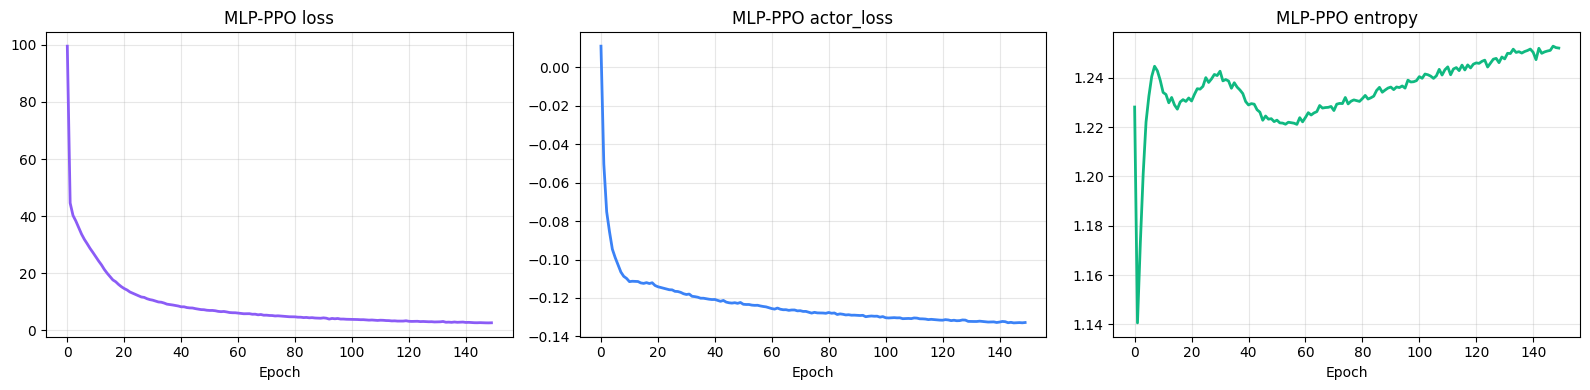

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, color in zip(axes, ['loss', 'actor_loss', 'entropy'], ['#8b5cf6', '#3b82f6', '#10b981']):
    ax.plot(history[key], color=color, linewidth=2)
    ax.set_title(f'MLP-PPO {key}'); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'compaction_mlp_ppo_training.png', dpi=150, bbox_inches='tight')
plt.show()

DDQN Partitioning

In [8]:
# This is a single cell
!unzip -q -o /content/Episodes.zip -d /content/episodes_data || echo "Unzip failed! Check if the file exists."
!find /content/episodes_data -name "*.csv" | head -n 5

unzip:  cannot find or open /content/Episodes.zip, /content/Episodes.zip.zip or /content/Episodes.zip.ZIP.
Unzip failed! Check if the file exists.
find: ‘/content/episodes_data’: No such file or directory


In [9]:
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

if Path('/kaggle').exists():
    OUTPUT_DIR = Path('/kaggle/working/lakegym_partition_agent')
elif Path('/content').exists():
    OUTPUT_DIR = Path('/content')
else:
    OUTPUT_DIR = Path('./lakegym_partition_agent')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_GLOBS =[
    '/kaggle/input/datasets/omerkarim404/partitioning/Episodes/**/*.csv',
    '/kaggle/working/**/*.csv',
    '/content/episodes_data/Episodes/**/*.csv'
]

TensorFlow Version: 2.18.0


In [10]:
# --- Environment Constants ---
LATENCY_MAX = 15000.0
FILE_COUNT_MAX = 2000.0
PARTITION_COST_MAX = 2.0
SKEW_MAX = 2.0

ACTION_COSTS_PARTITION = {0: 0.0, 4: 2.0, 5: 2.0, 6: 2.0, 7: 0.7}

PW_PRUNING = 0.55
PW_DELTA = 0.25
PW_SKEW = 0.10
PW_COST = 0.10

GW_LATENCY = 0.30
GW_FILES = 0.20
GW_PRUNING = 0.30
GW_UTIL = 0.20

def recompute_partition_rewards_vectorized(df):
    d = df.copy()
    a = d['action'].fillna(0).astype(int)
    cost = a.map(ACTION_COSTS_PARTITION).fillna(0.0)
    fc = d.get('next_file_count', d.get('file_count', 0.0)).astype(float)
    lat = d.get('next_latency_ms', d.get('latency_ms', 0.0)).astype(float)
    util = d.get('next_block_utilization', d.get('block_utilization', 0.0)).astype(float)
    skew = d.get('file_size_skew_kb', 0.0).astype(float)
    prune_curr = d.get('partition_pruning_ratio', 0.0).astype(float)
    prune_next = d.get('next_partition_pruning_ratio', prune_curr).astype(float)

    f_norm = (fc / FILE_COUNT_MAX).clip(0.0, 1.0)
    l_norm = (lat / LATENCY_MAX).clip(0.0, 1.0)
    u_norm = util.clip(0.0, 1.0)
    s_norm = (skew / SKEW_MAX).clip(0.0, 1.0)
    p_norm = prune_next.clip(0.0, 1.0)
    delta_p = (prune_next - prune_curr).clip(-1.0, 1.0)
    c_norm = (cost / PARTITION_COST_MAX).clip(0.0, 1.0)

    d['partition_reward'] = (PW_PRUNING * p_norm) + (PW_DELTA * delta_p) - (PW_SKEW * s_norm) - (PW_COST * c_norm)
    d['global_reward'] = -(GW_LATENCY * l_norm) - (GW_FILES * f_norm) + (GW_PRUNING * p_norm) + (GW_UTIL * u_norm)
    d['reward_preset'] = 'v5_2_recomputed'
    return d

files =[]
for p in DATA_GLOBS:
    files.extend(glob.glob(p, recursive=True))
files =[f for f in sorted(set(files)) if f.endswith('.csv') and 'transitions' in Path(f).name]

if not files:
    raise RuntimeError('No CSV files found. Check your DATA_GLOBS paths.')

print(f'Found {len(files)} CSV files. Loading...')
raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
sort_cols =[c for c in ['policy_name', 'episode', 'step'] if c in raw.columns]
if sort_cols: raw = raw.sort_values(sort_cols).reset_index(drop=True)
df = recompute_partition_rewards_vectorized(raw)
print(f'Recomputed rewards for {len(df)} total transitions.')

Found 6 CSV files. Loading...
Recomputed rewards for 6000 total transitions.


In [11]:
NUM_ACTIONS = 5
NUM_FEATURES = 14
WINDOW_SIZE = 20
EPISODE_LENGTH = 1000
GAMMA = 0.99

ACTION_MAP = {0: 0, 4: 1, 5: 2, 6: 3, 7: 4}
REVERSE_MAP = {v: k for k, v in ACTION_MAP.items()}
ACTION_NAMES =['NOOP', 'HOUR', 'REGION', 'EVENT_TYPE', 'REMOVE']

def extract_partition_features(df_target, prefix=''):
    p = prefix
    f = np.zeros((len(df_target), NUM_FEATURES), dtype=np.float32)
    f[:, 0] = np.clip(df_target[f'{p}latency_ms'].values / 15000.0, 0, 1)
    f[:, 1] = np.clip(df_target[f'{p}file_count'].values / 2000.0, 0, 1)
    ps = df_target[f'{p}partition_strategy'].values.astype(int)
    for i in range(4):
        f[:, 2+i] = (ps == i).astype(np.float32)
    f[:, 6] = np.clip(df_target[f'{p}partition_pruning_ratio'].values, 0, 1)
    f[:, 7] = np.clip(df_target[f'{p}avg_pruning_ratio'].values, 0, 1)
    f[:, 8] = df_target[f'{p}query_hist_time_range'].values
    f[:, 9] = df_target[f'{p}query_hist_region_filter'].values
    f[:, 10] = df_target[f'{p}query_hist_sensor_lookup'].values
    f[:, 11] = df_target[f'{p}query_hist_type_filter'].values
    f[:, 12] = df_target[f'{p}query_hist_full_scan'].values
    f[:, 13] = np.exp(-df_target[f'{p}steps_since_partition_change'].values / 30.0)
    return f

features_full = extract_partition_features(df)
N_TOTAL = len(df)
windows_full = np.zeros((N_TOTAL, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)

for start_idx in range(0, N_TOTAL, EPISODE_LENGTH):
    end_idx = min(start_idx + EPISODE_LENGTH, N_TOTAL)
    ep_features = features_full[start_idx:end_idx]
    ep_N = len(ep_features)
    for i in range(ep_N):
        s = max(0, i - WINDOW_SIZE + 1)
        seq = ep_features[s:i+1]
        pad = WINDOW_SIZE - len(seq)
        windows_full[start_idx + i, pad:, :] = seq

mask = df['action'].isin(ACTION_MAP.keys()).values
df_part = df[mask].reset_index(drop=True)
windows = windows_full[mask]
actions = np.array([ACTION_MAP[a] for a in df_part['action'].values], dtype=np.int32)

print(f'Total raw steps: {N_TOTAL}')
print(f'Valid partition transitions: {len(df_part)}')
print(f'Window shape: {windows.shape}')

Total raw steps: 6000
Valid partition transitions: 4990
Window shape: (4990, 20, 14)


In [12]:
# Physical improvements
lat_before  = df_part['latency_ms'].values.astype(np.float32)
lat_after   = df_part['next_latency_ms'].values.astype(np.float32)
lat_improvement = np.clip((lat_before - lat_after) / (lat_before + 1.0), -1, 1)

prune_before = df_part['partition_pruning_ratio'].values.astype(np.float32)
prune_after  = df_part['next_partition_pruning_ratio'].values.astype(np.float32)
prune_improvement = np.clip(prune_after - prune_before, -1, 1)

# Workload-partition alignment
qh = np.column_stack([
    df_part['query_hist_time_range'].values,
    df_part['query_hist_region_filter'].values,
    df_part['query_hist_sensor_lookup'].values,
    df_part['query_hist_type_filter'].values,
]).astype(np.float32)

dominant_query    = np.argmax(qh, axis=-1)
dominant_strength = np.max(qh, axis=-1)

ideal_action = np.zeros(len(actions), dtype=np.int32)
ideal_action[dominant_query == 0] = 1   # time_heavy -> HOUR
ideal_action[dominant_query == 1] = 2   # region_heavy -> REGION
ideal_action[dominant_query == 3] = 3   # type_heavy -> EVENT_TYPE

current_ps = df_part['partition_strategy'].values.astype(int)
already_correct = (current_ps == ideal_action) & (ideal_action > 0)
alignment = np.zeros(len(actions), dtype=np.float32)

mask_ok = already_correct
alignment[mask_ok & (actions == 0)]  =  0.5
alignment[mask_ok & (actions == 4)]  = -0.8
for a in [1, 2, 3]:
    alignment[mask_ok & (actions == a) & (actions != ideal_action)] = -0.5

mask_bad = ~already_correct
for a in [1, 2, 3]:
    match = mask_bad & (actions == a) & (ideal_action == a)
    alignment[match] = 1.0

alignment[mask_bad & (actions == 0)] = -0.3
alignment[mask_bad & (actions == 4) & (current_ps > 0)] = 0.3

clarity = np.clip(dominant_strength * 2.5 - 0.5, 0.3, 1.5)
alignment *= clarity

OUTCOME_WEIGHT    = 0.3
ALIGNMENT_WEIGHT  = 0.5
GLOBAL_WEIGHT     = 0.2

base_global = df_part['global_reward'].values.astype(np.float32)
custom_rewards = (
    OUTCOME_WEIGHT   * (0.5 * lat_improvement + 0.5 * prune_improvement) +
    ALIGNMENT_WEIGHT * alignment +
    GLOBAL_WEIGHT    * base_global
).astype(np.float32)

advantages = custom_rewards.copy()
for a_idx in range(NUM_ACTIONS):
    m = actions == a_idx
    if m.sum() > 1:
        advantages[m] = (advantages[m] - advantages[m].mean()) / (advantages[m].std() + 1e-8)

# Train/Val split
idx = np.random.permutation(len(windows))
split = int(0.85 * len(windows))
X_train, X_val = windows[idx[:split]], windows[idx[split:]]
a_train, a_val = actions[idx[:split]], actions[idx[split:]]
adv_train, adv_val = advantages[idx[:split]], advantages[idx[split:]]
cr_train, cr_val = custom_rewards[idx[:split]], custom_rewards[idx[split:]]
print(f'Training: {len(X_train)} | Validation: {len(X_val)}')

Training: 4241 | Validation: 749


In [13]:
class DuelingDDQN(tf.keras.Model):
    def __init__(self, num_actions, num_features, window_size=20, hidden_dim=128):
        super().__init__()
        self.flatten = tf.keras.layers.Flatten()
        self.shared1 = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.shared2 = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.val_fc = tf.keras.layers.Dense(hidden_dim // 2, activation='relu')
        self.val_out = tf.keras.layers.Dense(1)
        self.adv_fc = tf.keras.layers.Dense(hidden_dim // 2, activation='relu')
        self.adv_out = tf.keras.layers.Dense(num_actions)

    def call(self, x, training=False):
        h = self.flatten(x)
        h = self.shared1(h)
        h = self.shared2(h)
        val = self.val_out(self.val_fc(h))
        adv = self.adv_out(self.adv_fc(h))
        return val + adv - tf.reduce_mean(adv, axis=-1, keepdims=True), val

online_model = DuelingDDQN(NUM_ACTIONS, NUM_FEATURES, WINDOW_SIZE)
target_model = DuelingDDQN(NUM_ACTIONS, NUM_FEATURES, WINDOW_SIZE)
online_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES)))
target_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES)))
target_model.set_weights(online_model.get_weights())
online_model.summary()

Model: "dueling_ddqn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (1, 280)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (1, 128)                    │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (1, 128)                    │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (1, 1)                      │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (1, 5)                      │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,382 (271.02 KB)

 Trainable params: 69,382 (271.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from collections import deque

LR = 1e-4
EPOCHS = 150
BATCH_SIZE = 64
TARGET_UPDATE_FREQ = 50

optimizer = tf.keras.optimizers.Adam(LR)
replay_buffer = deque(maxlen=100000)
for i in range(len(X_train) - 1):
    replay_buffer.append((X_train[i], a_train[i], cr_train[i], X_train[i+1], 0.0))
replay_buffer.append((X_train[-1], a_train[-1], cr_train[-1], np.zeros_like(X_train[-1]), 1.0))
print(f'Replay buffer size: {len(replay_buffer)}')

history = {'loss': [], 'val_loss': []}
print('Starting Training...')

for epoch in range(EPOCHS):
    indices = np.random.permutation(len(replay_buffer))
    epoch_loss, batches = 0.0, 0

    for start in range(0, len(indices), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(indices))
        batch = [replay_buffer[indices[i]] for i in range(start, end)]
        states, acts, rews, next_states, dones = zip(*batch)
        states_t = tf.constant(np.array(states, dtype=np.float32))
        acts_t = tf.constant(np.array(acts, dtype=np.int32))
        rews_t = tf.constant(np.array(rews, dtype=np.float32))
        next_t = tf.constant(np.array(next_states, dtype=np.float32))
        dones_t = tf.constant(np.array(dones, dtype=np.float32))

        with tf.GradientTape() as tape:
            q_vals, _ = online_model(states_t, training=True)
            q_selected = tf.reduce_sum(q_vals * tf.one_hot(acts_t, NUM_ACTIONS), axis=-1)
            next_q, _ = online_model(next_t, training=False)
            next_actions = tf.argmax(next_q, axis=-1)
            target_q, _ = target_model(next_t, training=False)
            target_q_next = tf.reduce_sum(target_q * tf.one_hot(next_actions, NUM_ACTIONS), axis=-1)
            targets = rews_t + GAMMA * target_q_next * (1.0 - dones_t)
            loss = tf.reduce_mean(tf.square(targets - q_selected))

        grads = tape.gradient(loss, online_model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, online_model.trainable_variables))
        epoch_loss += float(loss)
        batches += 1
        if batches % TARGET_UPDATE_FREQ == 0:
            target_model.set_weights(online_model.get_weights())

    val_q, val_v = online_model(tf.constant(X_val), training=False)
    val_loss = float(tf.reduce_mean(tf.square(tf.squeeze(val_v, -1) - cr_val)))
    history['loss'].append(epoch_loss / max(batches, 1))
    history['val_loss'].append(val_loss)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Loss: {history['loss'][-1]:.4f} | Val: {val_loss:.4f}")

online_model.save_weights(OUTPUT_DIR / 'offline_partition_agent_ddqn.weights.h5')
print('Model saved.')

Replay buffer size: 4241
Starting Training...
Epoch 001/150 | Loss: 0.0905 | Val: 0.3119
Epoch 010/150 | Loss: 0.0404 | Val: 2.2847
Epoch 020/150 | Loss: 0.0411 | Val: 8.5033
Epoch 030/150 | Loss: 0.0458 | Val: 20.6838
Epoch 040/150 | Loss: 0.0426 | Val: 36.4443
Epoch 050/150 | Loss: 0.0491 | Val: 59.6250
Epoch 060/150 | Loss: 0.0519 | Val: 86.8616
Epoch 070/150 | Loss: 0.0556 | Val: 117.6734
Epoch 080/150 | Loss: 0.0606 | Val: 148.8391
Epoch 090/150 | Loss: 0.0626 | Val: 183.1393
Epoch 100/150 | Loss: 0.0716 | Val: 219.9498
Epoch 110/150 | Loss: 0.0790 | Val: 263.6248
Epoch 120/150 | Loss: 0.0766 | Val: 297.2666
Epoch 130/150 | Loss: 0.0840 | Val: 341.3823
Epoch 140/150 | Loss: 0.0920 | Val: 401.0896
Epoch 150/150 | Loss: 0.0897 | Val: 433.9980
Model saved.


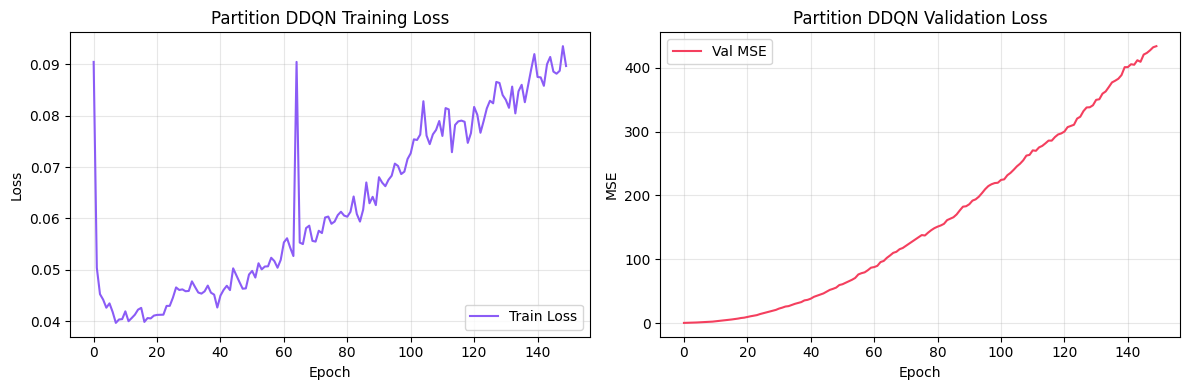

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss'], label='Train Loss', color='#8b5cf6')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Partition DDQN Training Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history['val_loss'], label='Val MSE', color='#f43f5e')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE')
ax2.set_title('Partition DDQN Validation Loss'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'partition_ddqn_training.png', dpi=150, bbox_inches='tight')
plt.show()

MLP PPO Partitioning

In [16]:
# This is a single cell
!unzip -q -o /content/Episodes.zip -d /content/episodes_data || echo "Unzip failed! Check if the file exists."
!find /content/episodes_data -name "*.csv" | head -n 5

unzip:  cannot find or open /content/Episodes.zip, /content/Episodes.zip.zip or /content/Episodes.zip.ZIP.
Unzip failed! Check if the file exists.
find: ‘/content/episodes_data’: No such file or directory


In [17]:
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

if Path('/kaggle').exists():
    OUTPUT_DIR = Path('/kaggle/working/lakegym_partition_agent')
elif Path('/content').exists():
    OUTPUT_DIR = Path('/content')
else:
    OUTPUT_DIR = Path('./lakegym_partition_agent')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_GLOBS =[
    '/kaggle/input/datasets/omerkarim404/partitioning/Episodes/**/*.csv',
    '/kaggle/working/**/*.csv',
    '/content/episodes_data/Episodes/**/*.csv'
]

TensorFlow Version: 2.18.0


In [18]:
# --- Environment Constants ---
LATENCY_MAX = 15000.0
FILE_COUNT_MAX = 2000.0
PARTITION_COST_MAX = 2.0
SKEW_MAX = 2.0

ACTION_COSTS_PARTITION = {0: 0.0, 4: 2.0, 5: 2.0, 6: 2.0, 7: 0.7}

PW_PRUNING = 0.55
PW_DELTA = 0.25
PW_SKEW = 0.10
PW_COST = 0.10

GW_LATENCY = 0.30
GW_FILES = 0.20
GW_PRUNING = 0.30
GW_UTIL = 0.20

def recompute_partition_rewards_vectorized(df):
    d = df.copy()
    a = d['action'].fillna(0).astype(int)
    cost = a.map(ACTION_COSTS_PARTITION).fillna(0.0)
    fc = d.get('next_file_count', d.get('file_count', 0.0)).astype(float)
    lat = d.get('next_latency_ms', d.get('latency_ms', 0.0)).astype(float)
    util = d.get('next_block_utilization', d.get('block_utilization', 0.0)).astype(float)
    skew = d.get('file_size_skew_kb', 0.0).astype(float)
    prune_curr = d.get('partition_pruning_ratio', 0.0).astype(float)
    prune_next = d.get('next_partition_pruning_ratio', prune_curr).astype(float)

    f_norm = (fc / FILE_COUNT_MAX).clip(0.0, 1.0)
    l_norm = (lat / LATENCY_MAX).clip(0.0, 1.0)
    u_norm = util.clip(0.0, 1.0)
    s_norm = (skew / SKEW_MAX).clip(0.0, 1.0)
    p_norm = prune_next.clip(0.0, 1.0)
    delta_p = (prune_next - prune_curr).clip(-1.0, 1.0)
    c_norm = (cost / PARTITION_COST_MAX).clip(0.0, 1.0)

    d['partition_reward'] = (PW_PRUNING * p_norm) + (PW_DELTA * delta_p) - (PW_SKEW * s_norm) - (PW_COST * c_norm)
    d['global_reward'] = -(GW_LATENCY * l_norm) - (GW_FILES * f_norm) + (GW_PRUNING * p_norm) + (GW_UTIL * u_norm)
    d['reward_preset'] = 'v5_2_recomputed'
    return d

files =[]
for p in DATA_GLOBS:
    files.extend(glob.glob(p, recursive=True))
files =[f for f in sorted(set(files)) if f.endswith('.csv') and 'transitions' in Path(f).name]

if not files:
    raise RuntimeError('No CSV files found. Check your DATA_GLOBS paths.')

print(f'Found {len(files)} CSV files. Loading...')
raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
sort_cols =[c for c in ['policy_name', 'episode', 'step'] if c in raw.columns]
if sort_cols: raw = raw.sort_values(sort_cols).reset_index(drop=True)
df = recompute_partition_rewards_vectorized(raw)
print(f'Recomputed rewards for {len(df)} total transitions.')

Found 6 CSV files. Loading...
Recomputed rewards for 6000 total transitions.


In [19]:
NUM_ACTIONS = 5
NUM_FEATURES = 14
WINDOW_SIZE = 20
EPISODE_LENGTH = 1000
GAMMA = 0.99

ACTION_MAP = {0: 0, 4: 1, 5: 2, 6: 3, 7: 4}
REVERSE_MAP = {v: k for k, v in ACTION_MAP.items()}
ACTION_NAMES =['NOOP', 'HOUR', 'REGION', 'EVENT_TYPE', 'REMOVE']

def extract_partition_features(df_target, prefix=''):
    p = prefix
    f = np.zeros((len(df_target), NUM_FEATURES), dtype=np.float32)
    f[:, 0] = np.clip(df_target[f'{p}latency_ms'].values / 15000.0, 0, 1)
    f[:, 1] = np.clip(df_target[f'{p}file_count'].values / 2000.0, 0, 1)
    ps = df_target[f'{p}partition_strategy'].values.astype(int)
    for i in range(4):
        f[:, 2+i] = (ps == i).astype(np.float32)
    f[:, 6] = np.clip(df_target[f'{p}partition_pruning_ratio'].values, 0, 1)
    f[:, 7] = np.clip(df_target[f'{p}avg_pruning_ratio'].values, 0, 1)
    f[:, 8] = df_target[f'{p}query_hist_time_range'].values
    f[:, 9] = df_target[f'{p}query_hist_region_filter'].values
    f[:, 10] = df_target[f'{p}query_hist_sensor_lookup'].values
    f[:, 11] = df_target[f'{p}query_hist_type_filter'].values
    f[:, 12] = df_target[f'{p}query_hist_full_scan'].values
    f[:, 13] = np.exp(-df_target[f'{p}steps_since_partition_change'].values / 30.0)
    return f

features_full = extract_partition_features(df)
N_TOTAL = len(df)
windows_full = np.zeros((N_TOTAL, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)

for start_idx in range(0, N_TOTAL, EPISODE_LENGTH):
    end_idx = min(start_idx + EPISODE_LENGTH, N_TOTAL)
    ep_features = features_full[start_idx:end_idx]
    ep_N = len(ep_features)
    for i in range(ep_N):
        s = max(0, i - WINDOW_SIZE + 1)
        seq = ep_features[s:i+1]
        pad = WINDOW_SIZE - len(seq)
        windows_full[start_idx + i, pad:, :] = seq

mask = df['action'].isin(ACTION_MAP.keys()).values
df_part = df[mask].reset_index(drop=True)
windows = windows_full[mask]
actions = np.array([ACTION_MAP[a] for a in df_part['action'].values], dtype=np.int32)

print(f'Total raw steps: {N_TOTAL}')
print(f'Valid partition transitions: {len(df_part)}')
print(f'Window shape: {windows.shape}')

Total raw steps: 6000
Valid partition transitions: 4990
Window shape: (4990, 20, 14)


In [20]:
# Physical improvements
lat_before  = df_part['latency_ms'].values.astype(np.float32)
lat_after   = df_part['next_latency_ms'].values.astype(np.float32)
lat_improvement = np.clip((lat_before - lat_after) / (lat_before + 1.0), -1, 1)

prune_before = df_part['partition_pruning_ratio'].values.astype(np.float32)
prune_after  = df_part['next_partition_pruning_ratio'].values.astype(np.float32)
prune_improvement = np.clip(prune_after - prune_before, -1, 1)

# Workload-partition alignment
qh = np.column_stack([
    df_part['query_hist_time_range'].values,
    df_part['query_hist_region_filter'].values,
    df_part['query_hist_sensor_lookup'].values,
    df_part['query_hist_type_filter'].values,
]).astype(np.float32)

dominant_query    = np.argmax(qh, axis=-1)
dominant_strength = np.max(qh, axis=-1)

ideal_action = np.zeros(len(actions), dtype=np.int32)
ideal_action[dominant_query == 0] = 1   # time_heavy -> HOUR
ideal_action[dominant_query == 1] = 2   # region_heavy -> REGION
ideal_action[dominant_query == 3] = 3   # type_heavy -> EVENT_TYPE

current_ps = df_part['partition_strategy'].values.astype(int)
already_correct = (current_ps == ideal_action) & (ideal_action > 0)
alignment = np.zeros(len(actions), dtype=np.float32)

mask_ok = already_correct
alignment[mask_ok & (actions == 0)]  =  0.5
alignment[mask_ok & (actions == 4)]  = -0.8
for a in [1, 2, 3]:
    alignment[mask_ok & (actions == a) & (actions != ideal_action)] = -0.5

mask_bad = ~already_correct
for a in [1, 2, 3]:
    match = mask_bad & (actions == a) & (ideal_action == a)
    alignment[match] = 1.0

alignment[mask_bad & (actions == 0)] = -0.3
alignment[mask_bad & (actions == 4) & (current_ps > 0)] = 0.3

clarity = np.clip(dominant_strength * 2.5 - 0.5, 0.3, 1.5)
alignment *= clarity

OUTCOME_WEIGHT    = 0.3
ALIGNMENT_WEIGHT  = 0.5
GLOBAL_WEIGHT     = 0.2

base_global = df_part['global_reward'].values.astype(np.float32)
custom_rewards = (
    OUTCOME_WEIGHT   * (0.5 * lat_improvement + 0.5 * prune_improvement) +
    ALIGNMENT_WEIGHT * alignment +
    GLOBAL_WEIGHT    * base_global
).astype(np.float32)

advantages = custom_rewards.copy()
for a_idx in range(NUM_ACTIONS):
    m = actions == a_idx
    if m.sum() > 1:
        advantages[m] = (advantages[m] - advantages[m].mean()) / (advantages[m].std() + 1e-8)

# Train/Val split
idx = np.random.permutation(len(windows))
split = int(0.85 * len(windows))
X_train, X_val = windows[idx[:split]], windows[idx[split:]]
a_train, a_val = actions[idx[:split]], actions[idx[split:]]
adv_train, adv_val = advantages[idx[:split]], advantages[idx[split:]]
cr_train, cr_val = custom_rewards[idx[:split]], custom_rewards[idx[split:]]
print(f'Training: {len(X_train)} | Validation: {len(X_val)}')

Training: 4241 | Validation: 749


In [21]:
class MlpPPO(tf.keras.Model):
    def __init__(self, num_actions, num_features, window_size=20, hidden_dim=128):
        super().__init__()
        self.flatten = tf.keras.layers.Flatten()
        self.fc1 = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.fc2 = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.fc3 = tf.keras.layers.Dense(hidden_dim // 2, activation='relu')
        self.actor_head = tf.keras.layers.Dense(num_actions, activation='softmax', name='actor')
        self.critic_head = tf.keras.layers.Dense(1, name='critic')

    def call(self, x, training=False):
        h = self.flatten(x)
        h = self.fc1(h)
        h = self.fc2(h)
        h = self.fc3(h)
        return self.actor_head(h), self.critic_head(h)

model = MlpPPO(NUM_ACTIONS, NUM_FEATURES, WINDOW_SIZE)
model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES)))
model.summary()

Model: "mlp_ppo_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (1, 280)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (1, 128)                    │          35,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (1, 128)                    │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ actor (Dense)                        │ (1, 5)                      │             325 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ critic (Dense)                       │ (1, 1)                      │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,126 (238.77 KB)

 Trainable params: 61,126 (238.77 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
LR = 3e-4
EPOCHS = 150
BATCH_SIZE = 128
CLIP_RATIO = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01

optimizer = tf.keras.optimizers.Adam(LR)

X_t = tf.constant(X_train, dtype=tf.float32)
A_t = tf.constant(a_train, dtype=tf.int32)
R_t = tf.constant(cr_train, dtype=tf.float32)
ADV_t = tf.constant(adv_train, dtype=tf.float32)

init_probs, _ = model(X_t, training=False)
old_logp = tf.math.log(tf.reduce_sum(init_probs * tf.one_hot(A_t, NUM_ACTIONS), axis=-1) + 1e-8).numpy()
OLD_LOGP = tf.constant(old_logp, dtype=tf.float32)

history = {'loss': [], 'actor_loss': [], 'critic_loss': [], 'entropy': [], 'val_loss': []}
print('Starting Training...')

for epoch in range(EPOCHS):
    indices = np.random.permutation(len(X_t))
    ep_m = {k: 0.0 for k in history if k != 'val_loss'}
    n_batches = 0

    for start in range(0, len(indices), BATCH_SIZE):
        bi = indices[start:start + BATCH_SIZE]
        with tf.GradientTape() as tape:
            probs, values = model(tf.gather(X_t, bi), training=True)
            values = tf.squeeze(values, -1)
            chosen = tf.reduce_sum(probs * tf.one_hot(tf.gather(A_t, bi), NUM_ACTIONS), -1)
            new_logp = tf.math.log(chosen + 1e-8)
            ratio = tf.exp(new_logp - tf.gather(OLD_LOGP, bi))
            adv_b = tf.gather(ADV_t, bi)
            actor_loss = -tf.reduce_mean(tf.minimum(
                ratio * adv_b, tf.clip_by_value(ratio, 1-CLIP_RATIO, 1+CLIP_RATIO) * adv_b))
            critic_loss = tf.reduce_mean(tf.square(tf.gather(R_t, bi) - values))
            entropy = -tf.reduce_mean(tf.reduce_sum(probs * tf.math.log(probs + 1e-8), -1))
            loss = actor_loss + VALUE_COEF * critic_loss - ENTROPY_COEF * entropy

        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 0.5)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        for k, v in zip(['loss','actor_loss','critic_loss','entropy'], [loss,actor_loss,critic_loss,entropy]):
            ep_m[k] += float(v)
        n_batches += 1

    for k in ep_m: history[k].append(ep_m[k] / max(n_batches, 1))
    _, val_v = model(tf.constant(X_val), training=False)
    history['val_loss'].append(float(tf.reduce_mean(tf.square(tf.squeeze(val_v,-1) - cr_val))))

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Loss: {history['loss'][-1]:.4f} | Entropy: {history['entropy'][-1]:.4f}")

model.save_weights(OUTPUT_DIR / 'offline_partition_agent_mlp_ppo.weights.h5')
print('Model saved.')

Starting Training...
Epoch 001/150 | Loss: -0.0775 | Entropy: 1.5822
Epoch 010/150 | Loss: -0.1464 | Entropy: 1.5545
Epoch 020/150 | Loss: -0.1659 | Entropy: 1.5468
Epoch 030/150 | Loss: -0.1773 | Entropy: 1.5458
Epoch 040/150 | Loss: -0.1758 | Entropy: 1.5466
Epoch 050/150 | Loss: -0.1848 | Entropy: 1.5405
Epoch 060/150 | Loss: -0.1902 | Entropy: 1.5410
Epoch 070/150 | Loss: -0.1781 | Entropy: 1.5390
Epoch 080/150 | Loss: -0.1834 | Entropy: 1.5421
Epoch 090/150 | Loss: -0.1917 | Entropy: 1.5402
Epoch 100/150 | Loss: -0.1828 | Entropy: 1.5370
Epoch 110/150 | Loss: -0.1839 | Entropy: 1.5424
Epoch 120/150 | Loss: -0.1819 | Entropy: 1.5405
Epoch 130/150 | Loss: -0.1898 | Entropy: 1.5419
Epoch 140/150 | Loss: -0.1860 | Entropy: 1.5379
Epoch 150/150 | Loss: -0.1900 | Entropy: 1.5422
Model saved.


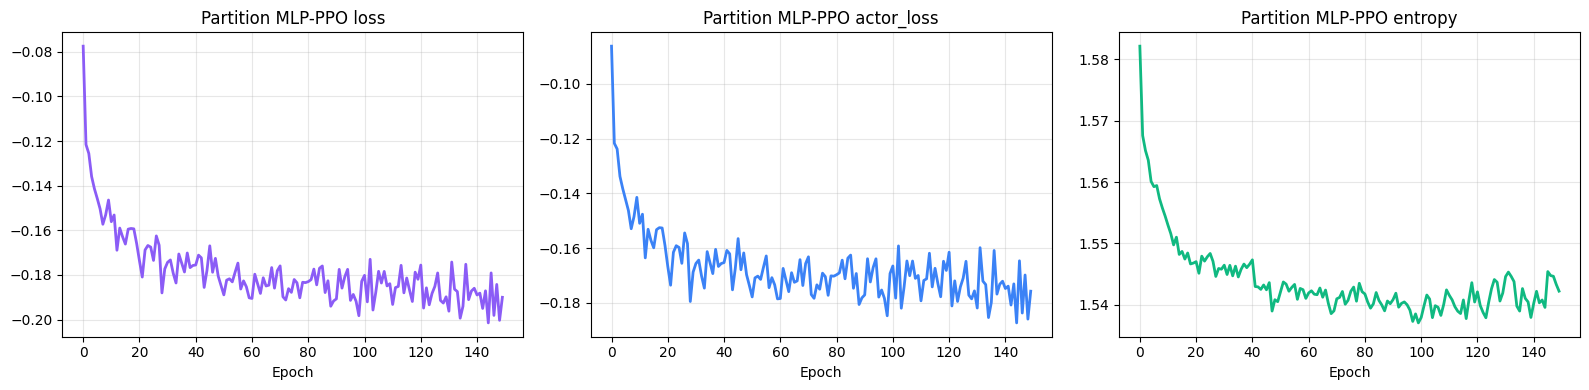

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, color in zip(axes, ['loss', 'actor_loss', 'entropy'], ['#8b5cf6', '#3b82f6', '#10b981']):
    ax.plot(history[key], color=color, linewidth=2)
    ax.set_title(f'Partition MLP-PPO {key}'); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'partition_mlp_ppo_training.png', dpi=150, bbox_inches='tight')
plt.show()